# Bayesian Neural Networks
---

## Overview

An Artificial Neural Network is a function $y=\Phi(x)$ such that 
$$
    x = l_0 \;,\quad l_i = s(W_i l_{i-1} + b_i)\;, \quad l_m = y\;, \quad i=1,\dots, m
$$
where $x \in \mathbb{R}^{d} $, $\theta = (W,b)$, $W_i \in \mathbb{R}^{h, d}$, $b \in \mathbb{R}^{h}$ and $s$ is a nonlinear function.

Given a dataset $\mathcal{D} = \{\mathcal{D_x}, \mathcal{D_y}\} = \{(x_i,y_i)\}_{i=1}^{N}$, the point estimates of the parameters $\hat{\theta} = (\hat{W},\hat{b})$ are determined by maximizing the likelihood $p(\mathcal{D_y} \mid \mathcal{D_x}, \theta)$ using backpropagation. We can compute likelihood because there is an underlying assumption that $p(y \mid x, \theta)$ belongs to a specific family of distributions, for instance by assuming normality th log likelihood is equivalent to the mean squared error.

In Bayesian Neural Networks, we introduce another assumption: the parameters of the neural network are realizations from a distribution $\theta \sim p(\theta)$. Applying Bayes' theorem we have that the posterior distribution is
$$
p(\theta \mid \mathcal{D}) = \frac{p(\mathcal{D_y} \mid \mathcal{D_x}, \theta) p(\theta)}{\int p(\mathcal{D_y} \mid \mathcal{D_x}, \theta') p(\theta') d\theta' }\; , 
$$
and the predictive distribution is 
$$
p(y \mid x, \mathcal{D}) = \int p(y \mid x, \theta') p(\theta' \mid \mathcal{D}) \; .
$$

From a pragmatic point of view, this means sampling
$$
\theta_1, \dots, \theta_S \sim p(\theta \mid \mathcal{D}) \; ,
$$
then the prediction of a new point $x^\text{new}$ is just
$$
y^\text{pred} = \mathbb{E}[y|x] = \frac{1}{S} \sum_{i=1}^{S} \Phi_{\theta_i}(x^\text{new}) \; ,
$$
and the uncertainty is
$$
\Sigma = \frac{1}{S-1} \sum_{i=1}^{S} (\Phi_{\theta_i}(x^\text{new})-y^\text{pred}) (\Phi_{\theta_i}(x^\text{new}) - y^\text{pred})^T \; .
$$


In [14]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

---

## Dataset


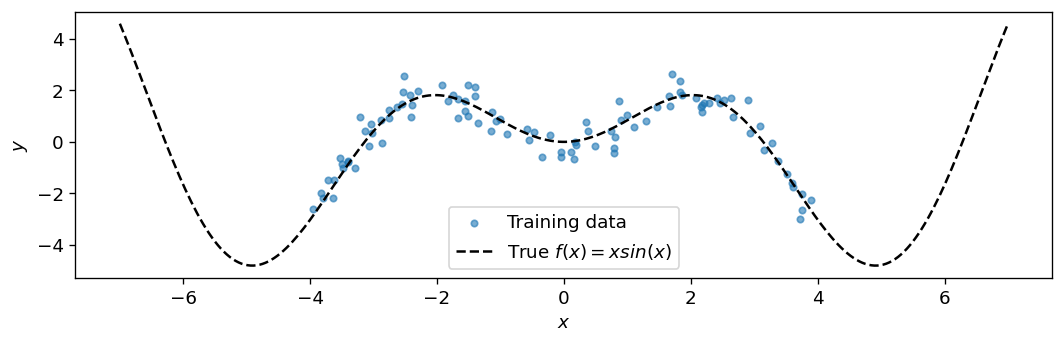

In [15]:
def true_function(x):
    return x * np.sin(x)

sigma_noise = 0.5
N_train = 100

X_train = np.random.uniform(-4, 4, N_train).astype(np.float32)
y_train = true_function(X_train) + np.random.normal(0, sigma_noise, N_train).astype(np.float32)

X_test = np.linspace(-7, 7, 300).astype(np.float32)
y_test_true = true_function(X_test)

# Convert to tensors shape (N, 1) for batched matrix ops
X_train_t = torch.from_numpy(X_train).unsqueeze(1)
y_train_t = torch.from_numpy(y_train).unsqueeze(1)
X_test_t  = torch.from_numpy(X_test).unsqueeze(1)

plt.figure(figsize=(9, 3))
plt.scatter(X_train, y_train, s=15, alpha=0.6, label='Training data')
plt.plot(X_test, y_test_true, 'k--', lw=1.5, label='True $f(x) = x sin(x)$')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.legend()
plt.tight_layout()
plt.show()

---

## Variational Inference and the ELBO


We introduce a variational distribution $q_{\boldsymbol{\phi}}(\mathbf{\theta})$ parameterised by $\boldsymbol{\phi}$, and minimise the KL divergence to the true posterior. The ELBO is:
$$
\mathcal{L}(\boldsymbol{\phi}) = \mathbb{E}_{q_{\boldsymbol{\phi}}}\!\left[\log p(\mathcal{D} \mid \theta)\right] - \mathrm{KL}\!\left[q_{\boldsymbol{\phi}}(\theta) \,\|\, p(\theta)\right]
$$

Maximising $\mathcal{L}$ is equivalent to minimising $\mathrm{KL}[q\|p(\cdot\mid\mathcal{D})]$.


We use a **mean-field** variational family: each weight $w_j$ is independently Gaussian,
$$
q_{\boldsymbol{\phi}}(\mathbf{\theta}) = \prod_j \mathcal{N}(w_j;\, \mu_j,\, \sigma_j^2)
$$
so the learnable parameters are $\boldsymbol{\phi} = \{\mu_j, \sigma_j\}_j$. We use the softplus reparameterisation $\sigma_j = \log(1+e^{\rho_j})$ and learn $\rho_j$ to ensure $\sigma_j > 0$.


We place a **Gaussian prior** on the weights:
$$
p(\mathbf{\theta}) = \prod_j \mathcal{N}(\theta_j;\, 0,\, \sigma_0^2)
$$

For two Gaussians $q = \mathcal{N}(\mu, \sigma^2)$ and $p = \mathcal{N}(0, \sigma_0^2)$, the KL has a closed form:
$$
\mathrm{KL}[q \| p] = \log\frac{\sigma_0}{\sigma} + \frac{\sigma^2 + \mu^2}{2\sigma_0^2} - \frac{1}{2}
$$


To differentiate through $\mathbb{E}_{q_{\boldsymbol{\phi}}}[\cdot]$ we use the **reparameterisation trick**:
$$
\theta_j = \mu_j + \sigma_j \cdot \varepsilon_j, \qquad \varepsilon_j \sim \mathcal{N}(0, 1)
$$
The gradient then flows through $\mu_j$ and $\sigma_j$ (or equivalently $\rho_j$).

---

## Implementing a Bayesian Linear Layer

Our Bayesian linear layer stores $(\boldsymbol{\mu}_W, \boldsymbol{\rho}_W)$ and $(\boldsymbol{\mu}_b, \boldsymbol{\rho}_b)$. At each forward pass it:
1. Samples $\varepsilon_W \sim \mathcal{N}(0, I)$ and $\varepsilon_b \sim \mathcal{N}(0, I)$
2. Computes $W = \boldsymbol{\mu}_W + \boldsymbol{\sigma}_W \odot \varepsilon_W$ and $b = \boldsymbol{\mu}_b + \boldsymbol{\sigma}_b \odot \varepsilon_b$
3. Computes $\mathbf{h} = \mathbf{x}W^\top + \mathbf{b}$
4. Returns $\mathbf{h}$ and the KL contribution $\mathrm{KL}[q(W,\mathbf{b})\|p(W,\mathbf{b})]$

In [ ]:
class BayesianLinear(nn.Module):
    """
    Parameters: mu_w, rho_w (weights), mu_b, rho_b (biases).
    sigma = softplus(rho) ensures positivity without constraints.
    """

    def __init__(self, in_features: int, out_features: int, prior_sigma: float = 1.0):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features
        self.prior_sigma  = prior_sigma

        pass

        # Variational parameters for weights: shape (out, in)


        # Variational parameters for biases: shape (out,)


    def _sigma(self, rho):
        pass
        
        return sigma

    
    def _kl_gaussian(self, mu, sigma):
        pass
        return kl
    

    def forward(self, x):
        pass

        # Softplus transformation
                                            # (out, in)
                                            # (out,)
        # Reparametrization


        # Standard linear transformation

        # KL contribution from this layer

        return out, kl

---

## Building the BNN

We stack Bayesian layers into a 3-layer MLP:
$$
f_{\mathbf{w}}(\mathbf{x}) = \mathbf{W}_3\,\tanh\!\left(\mathbf{W}_2\,\tanh\!\left(\mathbf{W}_1\,\mathbf{x} + \mathbf{b}_1\right) + \mathbf{b}_2\right) + \mathbf{b}_3
$$

The total KL divergence of the model is the sum over all layers:
$$
\mathrm{KL}[q_{\boldsymbol{\phi}}(\mathbf{w}) \| p(\mathbf{w})] = \sum_{\ell=1}^{3} \mathrm{KL}[q_{\boldsymbol{\phi}}(\mathbf{w}_\ell) \| p(\mathbf{w}_\ell)]
$$

In [ ]:
class BayesianMLP(nn.Module):
    def __init__(self, hidden: int = 32, prior_sigma: float = 1.0):
        super().__init__()
        pass

    def forward(self, x):
        pass 
        return h, total_kl

---

## The Loss Function

For a Gaussian likelihood $p(y \mid \mathbf{w}, \mathbf{x}) = \mathcal{N}(y;\, f_{\mathbf{w}}(\mathbf{x}),\, \sigma_{\text{obs}}^2)$, the log-likelihood over the training set is:
$$
\log p(\mathcal{D} \mid \mathbf{w}) = -\frac{N}{2}\log(2\pi\sigma_{\text{obs}}^2) - \frac{1}{2\sigma_{\text{obs}}^2}\sum_{i=1}^N (y_i - f_{\mathbf{w}}(\mathbf{x}_i))^2
$$

We approximate the expected log-likelihood with a single Monte Carlo sample per training step (one stochastic forward pass).



In [ ]:
def elbo_loss(y_pred, y_true, kl, N, sigma_obs=0.5):
    """
    Negative ELBO = NLL - (1/N) * KL
    Drop the constant terms and sum over the batch.
    """
    pass

    return nll + kl_scaled

---

## Training Loop

Each gradient step:
1. Sample weights $\hat{\mathbf{w}} \sim q_{\boldsymbol{\phi}}$ via the reparameterisation trick
2. Forward-pass through the network to get predictions $\hat{y}$
3. Compute $-\mathcal{L} = \text{NLL}(\hat{y}, y) + \frac{1}{N}\mathrm{KL}$
4. Back-propagate through the reparameterisation to update $\boldsymbol{\phi} = \{\mu_j, \rho_j\}$

<Figure size 768x576 with 0 Axes>

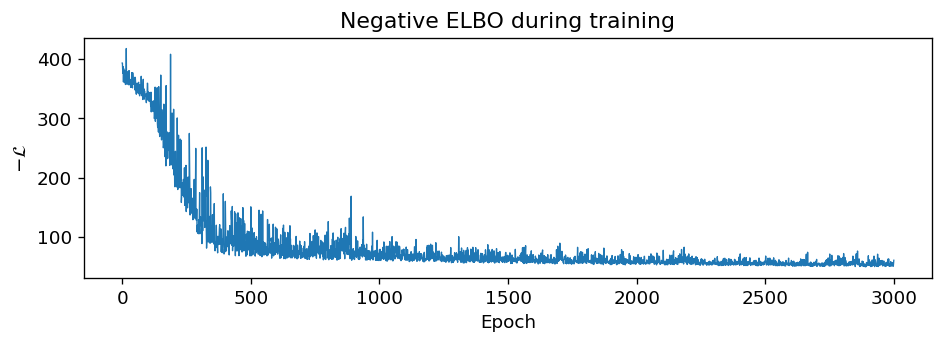

Final loss: 60.59


In [ ]:
model = BayesianMLP(hidden=32, prior_sigma=1.0)
optimiser = torch.optim.Adam(model.parameters(), lr=1e-2)

plt.suptitle('Variational Posterior: $(\\mu_j, \\sigma_j)$ per weight', fontsize=12)
plt.tight_layout(); plt.show()

N = len(X_train_t)
n_epochs = 3000
losses = []

for epoch in range(n_epochs):
    model.train()
    optimiser.zero_grad()

    y_pred, kl = model(X_train_t)

    loss = elbo_loss(y_pred, y_train_t, kl, N, sigma_obs=sigma_noise)
    loss.backward()
    optimiser.step()

    losses.append(loss.item())

plt.figure(figsize=(8, 3))
plt.plot(losses, lw=0.8)
plt.xlabel('Epoch'); plt.ylabel('$-\\mathcal{L}$')
plt.title('Negative ELBO during training')
plt.tight_layout(); plt.show()
print(f'Final loss: {losses[-1]:.2f}')

---

## Predictive Distribution via Monte Carlo

At test time we approximate the predictive distribution by drawing $S$ weight samples:
$$
p(y^* \mid \mathbf{x}^*, \mathcal{D}) = \int p(y^* \mid \mathbf{x}^*, \mathbf{w})\, p(\mathbf{w} \mid \mathcal{D})\, d\mathbf{w}
\;\approx\; \frac{1}{S}\sum_{s=1}^S p(y^* \mid \mathbf{x}^*, \hat{\mathbf{w}}_s)
$$
with $\hat{\mathbf{w}}_s \sim q_{\boldsymbol{\phi}}$.

The predictive mean and variance are:
$$
\mathbb{E}[y^*] \approx \frac{1}{S}\sum_s f_{\hat{\mathbf{w}}_s}(\mathbf{x}^*)
$$
$$
\mathrm{Var}[y^*] \approx \underbrace{\frac{1}{S}\sum_s f_{\hat{\mathbf{w}}_s}(\mathbf{x}^*)^2 - \left(\frac{1}{S}\sum_s f_{\hat{\mathbf{w}}_s}(\mathbf{x}^*)\right)^2}_{\text{epistemic}} + \underbrace{\sigma_{\text{obs}}^2}_{\text{aleatoric}}
$$

The epistemic uncertainty grows in regions without data. The aleatoric uncertaity $\sigma_{\text{obs}}^2$ is fixed.

In [ ]:
def predict_mc(model, X, n_samples=200):
    """Draw n_samples stochastic forward passes and return all predictions."""

    pass

    return np.array(preds)   # (n_samples, N_test)

S = 100
preds = predict_mc(model, X_test_t, n_samples=S)

mean_pred     = preds.mean(axis=0)
std_epistemic = preds.std(axis=0)
std_total     = np.sqrt(std_epistemic**2 + sigma_noise**2)

print(f'Predictions shape: {preds.shape}  (samples × test points)')

Predictions shape: (100, 300)  (samples × test points)


---

## Visualising the Predictive Distribution

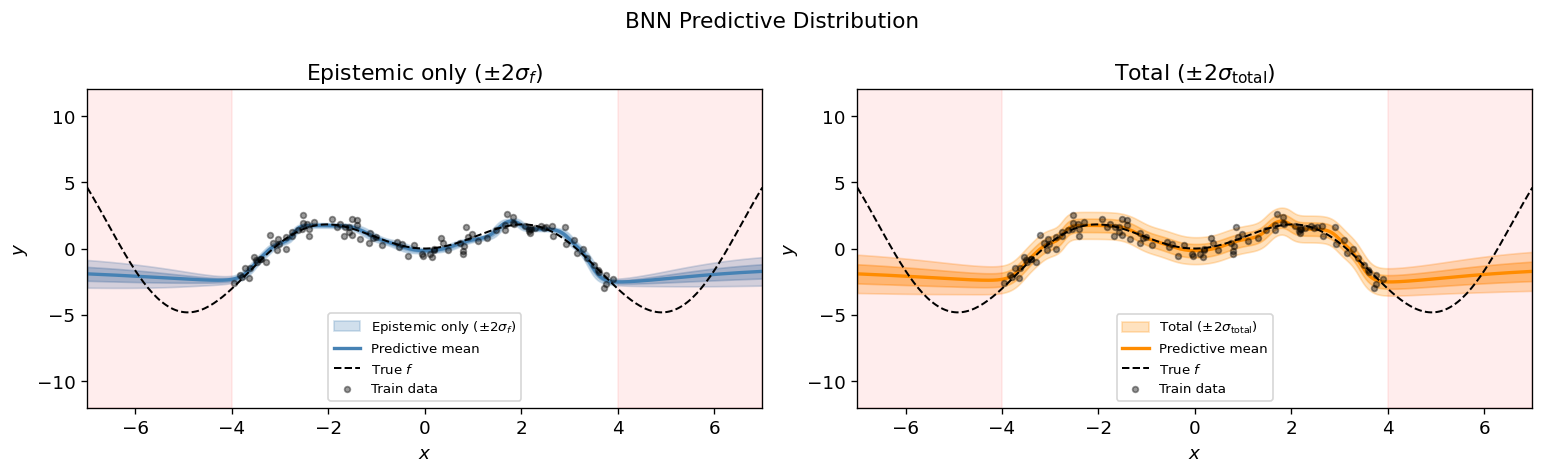

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (std, label, color) in zip(axes, [
    (std_epistemic, 'Epistemic only ($\\pm 2\\sigma_f$)', 'steelblue'),
    (std_total,     'Total ($\\pm 2\\sigma_{\\rm total}$)', 'darkorange'),
]):
    ax.fill_between(X_test, mean_pred - 2*std, mean_pred + 2*std,
                    alpha=0.25, color=color, label=label)
    ax.fill_between(X_test, mean_pred - std, mean_pred + std,
                    alpha=0.35, color=color)
    ax.plot(X_test, mean_pred, color=color, lw=2, label='Predictive mean')
    ax.plot(X_test, y_test_true, 'k--', lw=1.2, label='True $f$')
    ax.scatter(X_train, y_train, s=12, c='k', alpha=0.4, label='Train data', zorder=5)
    ax.axvspan(-7, -4, alpha=0.07, color='red')
    ax.axvspan( 4,  7, alpha=0.07, color='red')
    ax.set_xlim(-7, 7); ax.set_ylim(-12, 12)
    ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
    ax.legend(fontsize=8); ax.set_title(label)

plt.suptitle('BNN Predictive Distribution', fontsize=13)
plt.tight_layout(); plt.show()

---

## Learned Variational Parameters

For each weight in the network, the variational posterior is $q(w_j) = \mathcal{N}(\mu_j, \sigma_j^2)$. We can inspect how concentrated (low $\sigma_j$, high confidence) or diffuse (high $\sigma_j$, high uncertainty) these posteriors are.

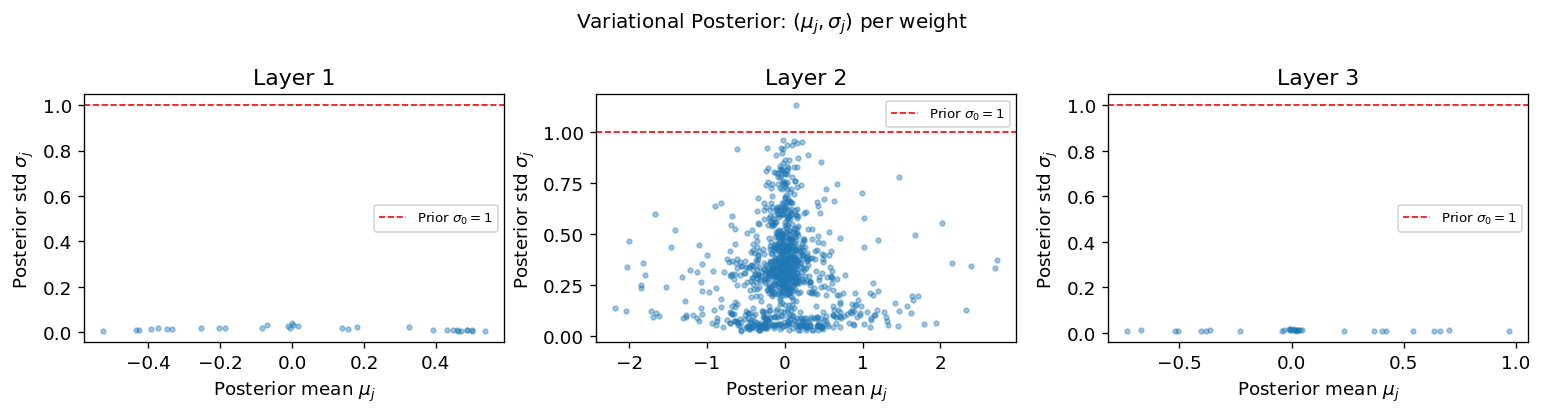

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
layer_names = ['Layer 1', 'Layer 2', 'Layer 3']

for ax, layer, name in zip(axes, [model.l1, model.l2, model.l3], layer_names):
    mus    = layer.mu_w.detach().flatten().numpy()
    sigmas = F.softplus(layer.rho_w).detach().flatten().numpy()

    ax.scatter(mus, sigmas, alpha=0.4, s=8)
    ax.axhline(1.0, color='red', ls='--', lw=1, label='Prior $\\sigma_0=1$')
    ax.set_xlabel('Posterior mean $\\mu_j$')
    ax.set_ylabel('Posterior std $\\sigma_j$')
    ax.set_title(name)
    ax.legend(fontsize=8)

plt.suptitle('Variational Posterior: $(\\mu_j, \\sigma_j)$ per weight', fontsize=12)
plt.tight_layout(); plt.show()

---

## Comparison with a Deterministic MLP

A standard MLP trained with MSE loss corresponds to maximising the log-likelihood alone:
$$
\hat{\mathbf{w}} = \arg\min_{\mathbf{w}} \frac{1}{N}\sum_{i=1}^N (y_i - f_{\mathbf{w}}(\mathbf{x}_i))^2
$$
which gives a single prediction per input with no uncertainty estimate.

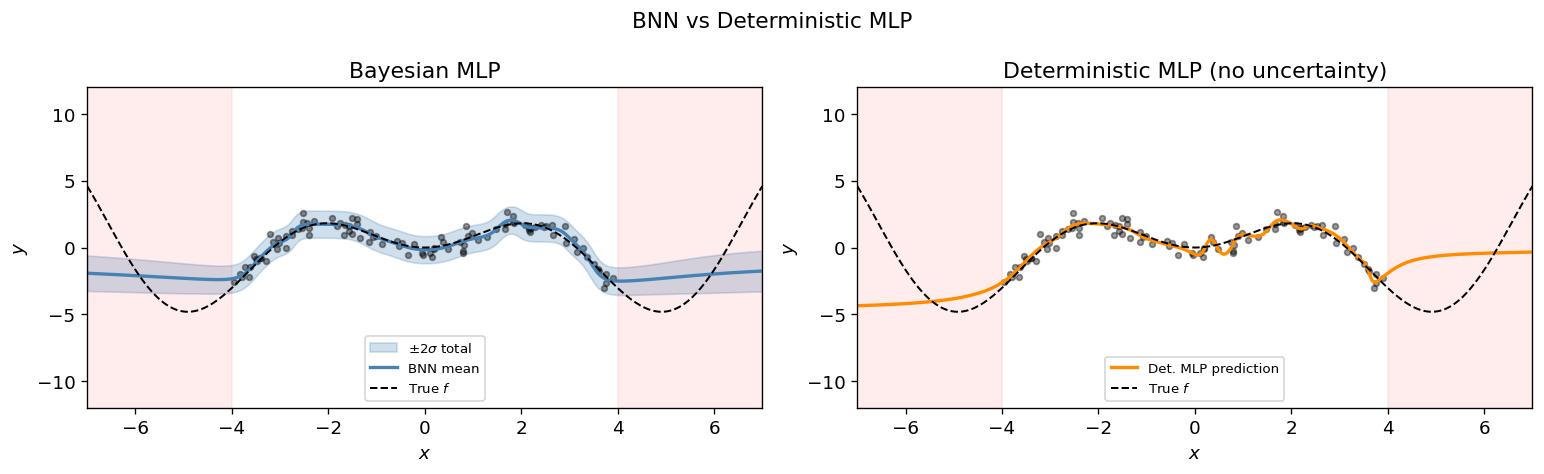

In [ ]:
class DeterministicMLP(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 1)
        )
        
    def forward(self, x):
        return self.net(x)

det_model = DeterministicMLP(hidden=32)
det_opt   = torch.optim.Adam(det_model.parameters(), lr=1e-2)

for epoch in range(3000):
    det_model.train()
    det_opt.zero_grad()
    pred = det_model(X_train_t)
    loss = F.mse_loss(pred, y_train_t)
    loss.backward()
    det_opt.step()

with torch.no_grad():
    det_pred = det_model(X_test_t).squeeze().numpy()

# Comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# BNN
ax = axes[0]
ax.fill_between(X_test, mean_pred - 2*std_total, mean_pred + 2*std_total,
                alpha=0.25, color='steelblue', label='$\\pm 2\\sigma$ total')
ax.plot(X_test, mean_pred, 'steelblue', lw=2, label='BNN mean')
ax.plot(X_test, y_test_true, 'k--', lw=1.2, label='True $f$')
ax.scatter(X_train, y_train, s=12, c='k', alpha=0.4)
ax.axvspan(-7,-4,alpha=0.07,color='red'); ax.axvspan(4,7,alpha=0.07,color='red')
ax.set_xlim(-7,7); ax.set_ylim(-12,12)
ax.set_title('Bayesian MLP'); ax.legend(fontsize=8)

# Deterministic
ax = axes[1]
ax.plot(X_test, det_pred, 'darkorange', lw=2, label='Det. MLP prediction')
ax.plot(X_test, y_test_true, 'k--', lw=1.2, label='True $f$')
ax.scatter(X_train, y_train, s=12, c='k', alpha=0.4)
ax.axvspan(-7,-4,alpha=0.07,color='red'); ax.axvspan(4,7,alpha=0.07,color='red')
ax.set_xlim(-7,7); ax.set_ylim(-12,12)
ax.set_title('Deterministic MLP (no uncertainty)'); ax.legend(fontsize=8)

for ax in axes:
    ax.set_xlabel('$x$'); ax.set_ylabel('$y$')

plt.suptitle('BNN vs Deterministic MLP', fontsize=13)
plt.tight_layout(); plt.show()